In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from sklearn.neighbors import NearestNeighbors
from pyproj import Transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df_divar = pd.read_csv('Divar.csv')
df_city = pd.read_csv('iran_city_classification.csv')
df_divar = df_divar.merge(df_city ,  left_on='city_slug' , right_on='نام شهر' , how='left')
df_divar = df_divar.drop(columns='نام شهر')  

C:\Users\pouria\AppData\Local\Temp\ipykernel_17400\1474697002.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df_divar = pd.read_csv('Divar.csv')


In [3]:
main_cats = ['residential-sell', 'residential-rent', 'commercial-sell', 'commercial-rent']

df_model = df_divar[df_divar["cat2_slug"].isin(main_cats)].copy()

In [4]:
text = (
    df_model["description"].fillna("") + " " +
    df_model["title"].fillna("")
)


villa_categories = [
    "villa",
    "house-villa-sell",
    "house-villa-rent"
]


villa_mask = df_model["cat3_slug"].isin(
    villa_categories
)


full_option_mask = text.str.contains(
    "فول امکانات|امکانات کامل|تمام امکانات",
    regex=True,
    na=False
)

df_model.loc[
    full_option_mask & ~villa_mask,
    [
        "has_elevator",
        "has_warehouse",
        "has_parking"
    ]
] = "true"

df_model.loc[
    full_option_mask & villa_mask,
    [
        "has_warehouse",
        "has_parking",
        "has_pool",
        "has_sauna",
        "has_jacuzzi",
        "has_barbecue"
    ]
] = "true"


for i, col in zip(["بالکن","آسانسور","نگهبان","باربیکیو","استخر","سونا","جکوزی","پارکینگ","انباری|انبار","سند تجاری"],
             ["has_balcony","has_elevator","has_security_guard","has_barbecue","has_pool"
              ,"has_sauna","has_jacuzzi","has_parking","has_warehouse","has_business_deed"]):

    mask = text.str.contains(
        i,
        regex=True,
        na=False
    )

    df_model.loc[mask,col] = "true"


In [5]:
binary_cols = [
    'has_business_deed',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking',
    'is_rebuilt',
    'has_water',
    'has_electricity',
    'has_gas',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
    'has_jacuzzi',
    'has_sauna'
]

for col in binary_cols:
    df_model[col] = df_model[col].replace({
            'true': True,
            'True': True,
            'false': False,
            'False': False,
            'unselect': np.nan
        })


for col in binary_cols:
    df_model[col] = df_model[col].fillna(False)

C:\Users\pouria\AppData\Local\Temp\ipykernel_17400\3023284984.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col] = df_model[col].fillna(False)


In [6]:
df_model['floor_material'] = df_model['floor_material'].replace('unselect' , np.nan)

In [7]:
weights = {
    'has_business_deed': 1,
    'has_balcony': 1,
    'has_elevator': 2,
    'has_warehouse': 2,
    'has_parking': 3,
    'is_rebuilt': 2,
    'has_water': 1,
    'has_electricity': 1,
    'has_gas': 1,
    'has_security_guard': 2,
    'has_barbecue': 1,
    'has_pool': 3,
    'has_jacuzzi': 3,
    'has_sauna': 3
}

df_model['amenity_score'] = sum(df_model[col] * weight for col , weight in weights.items())

df_model = df_model.drop(columns=binary_cols)

In [8]:
# cat3_slug
df_model = df_model.dropna(subset=["cat3_slug"])


# rooms_count
rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}

df_model["rooms_count"] = df_model["rooms_count"].map(rooms_map)


# construction_year

persian_digits = str.maketrans(
    '۰۱۲۳۴۵۶۷۸۹',
    '0123456789'
)

df_model["construction_year"] = (df_model["construction_year"].astype("string").str.translate(persian_digits))
df_model.loc[df_model["construction_year"] == "قبل از 1370", "construction_year"] = "1369"
df_model["construction_year"] = pd.to_numeric(df_model["construction_year"], errors="coerce")


# building_size
df_model["building_size"] = pd.to_numeric(df_model["building_size"], errors="coerce")
df_model = df_model.dropna(subset=["building_size"])


# floor
df_model["floor"] = (df_model["floor"].replace("30+", "30"))
df_model["floor"] = pd.to_numeric(df_model["floor"], errors="coerce")


# total_floors_count
df_model["total_floors_count"] = (df_model["total_floors_count"].replace({"unselect": np.nan, "30+": "30"}))
df_model["total_floors_count"] = pd.to_numeric(df_model["total_floors_count"], errors="coerce")


#unit_per_floor
df_model["unit_per_floor_more_than_8"] = (df_model["unit_per_floor"].astype("string").eq("more_than_8").fillna(False).astype(int))
df_model["unit_per_floor"] = (df_model["unit_per_floor"].replace({"unselect": np.nan, "more_than_8": "9"}))
df_model["unit_per_floor"] = pd.to_numeric(df_model["unit_per_floor"], errors="coerce")

In [9]:
price_cols = [
    "price_value",
    "credit_value",
    "rent_value",
    "transformable_rent",
    "transformable_credit"
]

for col in price_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")


sale_mask = df_model["cat2_slug"].isin(["residential-sell", "commercial-sell"])
rent_mask = df_model["cat2_slug"].isin(["residential-rent", "commercial-rent"])


df_model["target_price"] = np.nan

df_model.loc[sale_mask, "target_price"] = (df_model.loc[sale_mask, "price_value"])

final_rent = np.where(
    df_model["rent_value"].notna() &
    (df_model["rent_value"] != 0),
    df_model["rent_value"],
    df_model["transformable_rent"]
)


final_credit = np.where(
    df_model["credit_value"].notna() &
    (df_model["credit_value"] != 0),
    df_model["credit_value"],
    df_model["transformable_credit"]
)

rent_to_credit_factor = 1_000_000 / 30_000   

df_model.loc[rent_mask, "target_price"] = (final_credit[rent_mask] + 
                                           final_rent[rent_mask] * rent_to_credit_factor)


df_model = df_model[df_model["target_price"].notna() & (df_model["target_price"] > 0)].copy()


df_model["target_log10"] = np.log10(df_model["target_price"])
Q1 = df_model["target_log10"].quantile(0.25)
Q3 = df_model["target_log10"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (
    (df_model["target_log10"] < lower) |
    (df_model["target_log10"] > upper)
)
df_model = df_model.loc[~outlier_mask].copy()



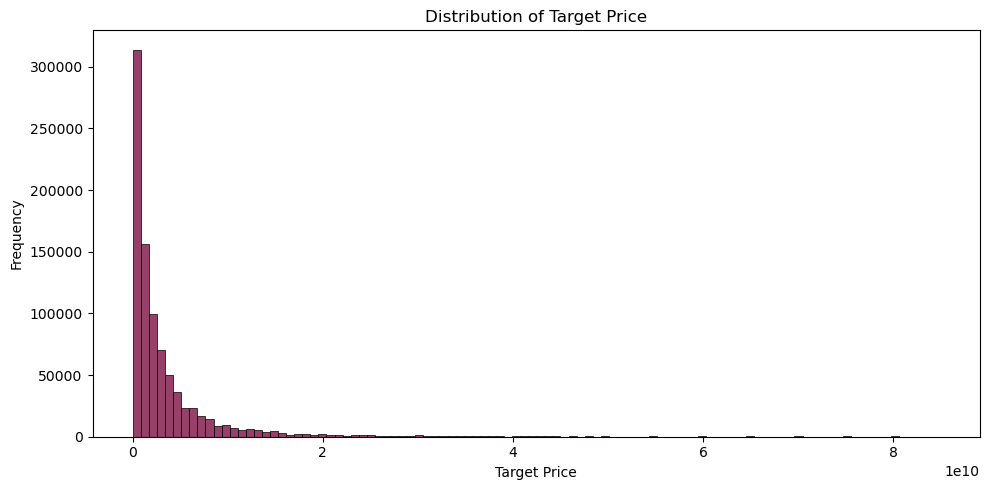

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(df_model["target_price"], bins=100, color="#730038")

plt.title("Distribution of Target Price")
plt.xlabel("Target Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

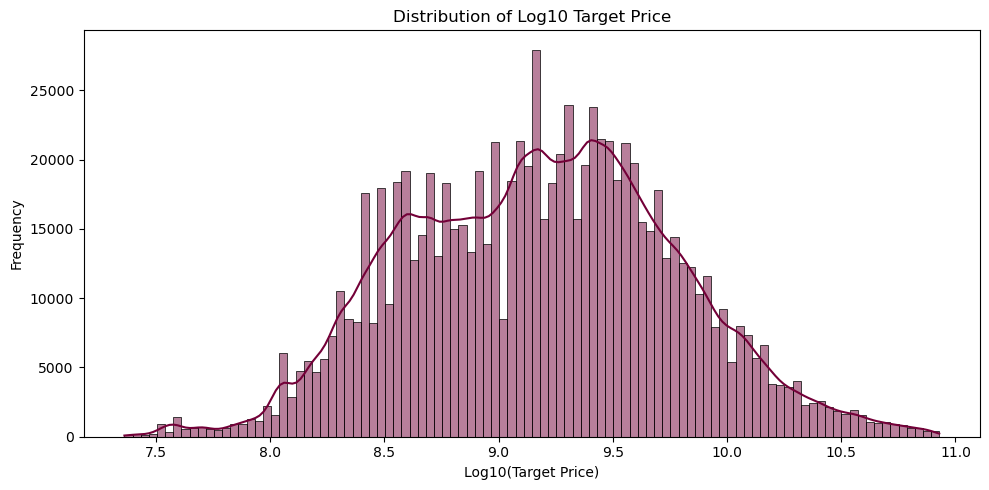

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(df_model["target_log10"], bins=100, kde=True, color="#730038")

plt.title("Distribution of Log10 Target Price")
plt.xlabel("Log10(Target Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
plot_mask = ((df_model["cat3_slug"] == "plot-old") & (df_model["rooms_count"].isna()))
df_model.loc[plot_mask, "rooms_count"] = 0

In [13]:
def fit_building_size_thresholds(data):
    stats = (data.groupby("cat3_slug")["building_size"].agg(q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75)))
    stats["iqr"] = stats["q3"] - stats["q1"]
    stats["upper_bound"] = (stats["q3"] + 3 * stats["iqr"])

    return stats["upper_bound"].to_dict()



def apply_building_size_cap(data, threshold_map):
    data = data.copy()
    upper = data["cat3_slug"].map(threshold_map)

    data["building_size_outlier"] = (data["building_size"] > upper).astype(int)
    mask = (data["building_size"].notna() & upper.notna() & (data["building_size"] > upper))
    data.loc[mask, "building_size"] = upper[mask]

    return data

In [14]:
print(df_model[["city_slug","neighborhood_slug","location_latitude", "location_longitude"]].isna().all(axis=1).sum())
df_model = df_model[~(df_model[["city_slug", "neighborhood_slug",
                    "location_latitude", "location_longitude"]].isna().all(axis=1))]

2


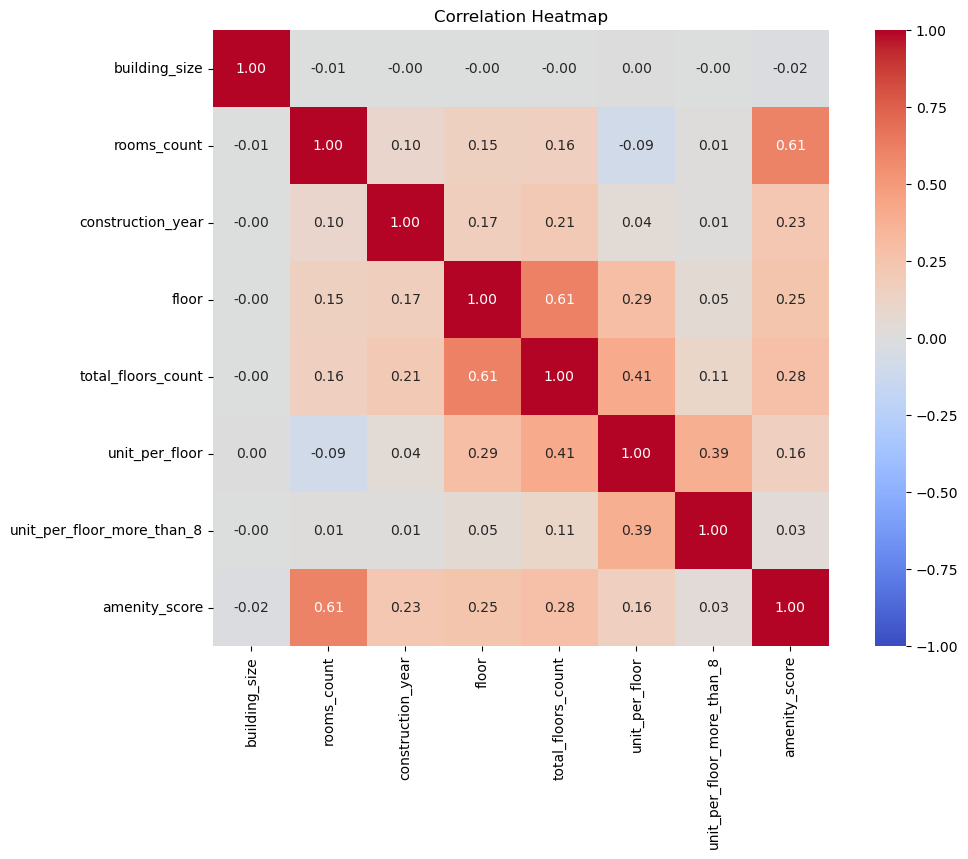

In [15]:
feature_cols = [
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "unit_per_floor_more_than_8",
    "amenity_score"

]
corr = df_model[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap")
plt.show()


In [16]:
feature_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "floor_material",
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "unit_per_floor_more_than_8",
    "amenity_score",
    "building_size_outlier"
]
categorical_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "floor_material"
]
numeric_cols = [
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "unit_per_floor_more_than_8",
    "amenity_score",
    "building_size_outlier"
]
onehot_cols = [
    "cat2_slug",
    "cat3_slug",
    "floor_material"
]

frequency_cols = [
    "city_slug",
    "neighborhood_slug"
]


In [18]:
train_data, test_data = train_test_split(
    df_model,
    test_size=0.15,
    random_state=42
)


kf = KFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)


median_cols = [
    "construction_year",
    "rooms_count"
]

structural_cols = [
    "floor",
    "total_floors_count",
    "unit_per_floor"
]

r2_scores_dummy = []
mae_scores_dummy = []
mse_scores_dummy = []

r2_scores_linear = []
mae_scores_linear = []
mse_scores_linear = []

r2_scores_catboost = []
mae_scores_catboost = []
mse_scores_catboost = []

for train_idx, val_idx in kf.split(train_data):

    fold_train = train_data.iloc[train_idx].copy()
    fold_val = train_data.iloc[val_idx].copy()


    known_train = fold_train[
        fold_train['neighborhood_slug'].notna() &
        fold_train['location_latitude'].notna() &
        fold_train['location_longitude'].notna()
    ].copy()
    missing_train = fold_train[
        fold_train['neighborhood_slug'].isna() &
        fold_train['location_latitude'].notna() &
        fold_train['location_longitude'].notna()
    ].copy()
    
    cord_known_train = known_train[
        ['location_latitude', 'location_longitude']
    ]

    cord_missing_train = missing_train[
        ['location_latitude', 'location_longitude']
    ]

    near_neighbors = NearestNeighbors(n_neighbors=1)

    near_neighbors.fit(cord_known_train)

    distances, indices = near_neighbors.kneighbors(
        cord_missing_train
    )
    fold_train.loc[
        missing_train.index,
        'neighborhood_slug'
    ] = known_train.iloc[
        indices.flatten()
    ]['neighborhood_slug'].values
    
    
    
    missing_val = fold_val[
        fold_val['neighborhood_slug'].isna() &
        fold_val['location_latitude'].notna() &
        fold_val['location_longitude'].notna()
    ].copy()

    cord_missing_val = missing_val[
        ['location_latitude', 'location_longitude']
    ]

    
    distances_val, indices_val = near_neighbors.kneighbors(
        cord_missing_val
    )

    
    fold_val.loc[
        missing_val.index,
        'neighborhood_slug'
    ] = known_train.iloc[
        indices_val.flatten()
    ]['neighborhood_slug'].values
    

    
    fold_train['neighborhood_slug'] = (
        fold_train['neighborhood_slug'].fillna('unknown')
    )
    fold_val['neighborhood_slug'] = (
        fold_val['neighborhood_slug'].fillna('unknown')
    )
  
    lat_mean = fold_train.groupby('city_slug')['location_latitude'].mean()
    lon_mean = fold_train.groupby('city_slug')['location_longitude'].mean()
    city_floor_mode = fold_train.groupby('city_slug')['floor_material'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    global_floor_mode = fold_train['floor_material'].mode().iloc[0]
    
    fold_train['location_latitude'] = fold_train['location_latitude'].fillna(fold_train['city_slug'].map(lat_mean))
    fold_train['location_longitude'] = fold_train['location_longitude'].fillna(fold_train['city_slug'].map(lon_mean))
    fold_val['location_latitude'] = fold_val['location_latitude'].fillna(fold_val['city_slug'].map(lat_mean))
    fold_val['location_longitude'] = fold_val['location_longitude'].fillna(fold_val['city_slug'].map(lon_mean))

    
    
    fold_train['floor_material'] = fold_train['floor_material'].fillna(fold_train['city_slug'].map(city_floor_mode)).fillna(global_floor_mode)
    fold_val['floor_material'] = fold_val['floor_material'].fillna(fold_val['city_slug'].map(city_floor_mode)).fillna(global_floor_mode)
    
    building_thresholds = fit_building_size_thresholds(fold_train)
    fold_train = apply_building_size_cap(fold_train, building_thresholds)
    fold_val = apply_building_size_cap(fold_val, building_thresholds)
    
    median_imputer = SimpleImputer(strategy="median", add_indicator=True)
    train_median = median_imputer.fit_transform(fold_train[median_cols])
    val_median = median_imputer.transform(fold_val[median_cols])
    
    
    median_feature_names = (median_imputer.get_feature_names_out(median_cols))
    train_median = pd.DataFrame(train_median, columns=median_feature_names, index=fold_train.index)
    val_median = pd.DataFrame(val_median, columns=median_feature_names, index=fold_val.index)
        
    
    fold_train = fold_train.drop(columns = median_cols)
    fold_val = fold_val.drop(columns = median_cols)
    
    
    fold_train = pd.concat([fold_train, train_median], axis=1)
    fold_val = pd.concat([fold_val, val_median], axis=1)


    structural_imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
    train_structural = structural_imputer.fit_transform(fold_train[structural_cols])
    val_structural = structural_imputer.transform(fold_val[structural_cols])
    

    structural_feature_names = (structural_imputer.get_feature_names_out(structural_cols))
    train_structural = pd.DataFrame(train_structural, columns=structural_feature_names, index=fold_train.index)
    val_structural = pd.DataFrame(val_structural, columns=structural_feature_names, index=fold_val.index)
      
    
    fold_train = fold_train.drop(columns=structural_cols)
    fold_val = fold_val.drop(columns=structural_cols)
    

    fold_train = pd.concat([fold_train, train_structural], axis=1)
    fold_val = pd.concat([fold_val, val_structural], axis=1)
    

    for col in frequency_cols:
        
        freq_map = fold_train[col].value_counts(normalize=True)
        fold_train[col + "_freq"] = fold_train[col].map(freq_map)
        fold_val[col + "_freq"] = (fold_val[col].map(freq_map).fillna(0))
        
        
        
    onehot_encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)   
    train_onehot = onehot_encoder.fit_transform(fold_train[onehot_cols])
    val_onehot = onehot_encoder.transform(fold_val[onehot_cols])
    onehot_feature_names = onehot_encoder.get_feature_names_out(onehot_cols)
    train_onehot = pd.DataFrame(train_onehot,columns=onehot_feature_names,index=fold_train.index)
    val_onehot = pd.DataFrame(val_onehot,columns=onehot_feature_names,index=fold_val.index)
    fold_train = pd.concat([fold_train, train_onehot],axis=1)
    fold_val = pd.concat([fold_val, val_onehot],axis=1)
    feature_cols = (
        numeric_cols
        + [col + "_freq" for col in frequency_cols]
        + list(onehot_feature_names)
    )

    X_train = fold_train[feature_cols].copy()
    X_val = fold_val[feature_cols].copy()
    y_train = fold_train["target_log10"].copy()
    y_val = fold_val["target_log10"].copy()
    
    corr = X_train.select_dtypes(include=np.number).corr().abs()

    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            value = corr.iloc[i, j]

            if value >= 0.7:
                pairs.append({
                    "feature_1": corr.columns[i],
                    "feature_2": corr.columns[j],
                    "correlation": round(value, 3)
                })

    overlap_table = pd.DataFrame(pairs).sort_values(
        "correlation", ascending=False
    )

    overlap_table
    


    model_dummy = DummyRegressor()
    model_dummy.fit(X_train, y_train)
    pred_log_dummy = model_dummy.predict(X_val)
    pred_dummy = 10 ** pred_log_dummy
    actual_dummy = 10 ** y_val


    r2_scores_dummy.append(r2_score(actual_dummy, pred_dummy))
    mae_scores_dummy.append(mean_absolute_error(actual_dummy, pred_dummy))
    mse_scores_dummy.append(mean_squared_error(actual_dummy, pred_dummy))



    model_linear = LinearRegression()
    model_linear.fit(X_train, y_train)
    pred_log_linear = model_linear.predict(X_val)
    pred_linear = 10 ** pred_log_linear
    actual_linear = 10 ** y_val    
    r2_scores_linear.append(r2_score(actual_linear, pred_linear))
    mae_scores_linear.append(mean_absolute_error(actual_linear, pred_linear))
    mse_scores_linear.append(mean_squared_error(actual_linear, pred_linear))
        
    catboost_features = (
        categorical_cols
        + numeric_cols
        + [col + "_freq" for col in frequency_cols]
    )

    X_train = fold_train[catboost_features].copy()
    X_val = fold_val[catboost_features].copy()
    
    model_catboost = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="R2",
        random_seed=42,
        verbose=100
    )
    param_grid = {
        "learning_rate": [0.03, 0.05, 0.1],
        "depth": [6, 8, 10]
    }
    grid_search = GridSearchCV(
        estimator=model_catboost,
        param_grid=param_grid,
        cv=2,
        scoring="r2",
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(
        X_train,
        y_train,
        cat_features=categorical_cols
    )
  
    best_catboost = grid_search.best_estimator_
    
    pred_log_catboost = best_catboost.predict(X_val)
    pred_catboost = 10 ** pred_log_catboost
    actual_catboost = 10 ** y_val  
      
      
        
    r2_scores_catboost.append(r2_score(actual_catboost, pred_catboost))
    mae_scores_catboost.append(mean_absolute_error(actual_catboost, pred_catboost))
    mse_scores_catboost.append(mean_squared_error(actual_catboost, pred_catboost))
    


Fitting 2 folds for each of 9 candidates, totalling 18 fits
0:	learn: 0.1226801	total: 217ms	remaining: 1m 48s
100:	learn: 0.7508020	total: 12.3s	remaining: 48.7s
200:	learn: 0.7653991	total: 24.6s	remaining: 36.6s
300:	learn: 0.7740887	total: 36.6s	remaining: 24.2s
400:	learn: 0.7802539	total: 48.8s	remaining: 12.1s
499:	learn: 0.7854463	total: 1m	remaining: 0us
Fitting 2 folds for each of 9 candidates, totalling 18 fits
0:	learn: 0.1218807	total: 133ms	remaining: 1m 6s
100:	learn: 0.7495536	total: 12.2s	remaining: 48.1s
200:	learn: 0.7643761	total: 24.5s	remaining: 36.4s
300:	learn: 0.7729080	total: 37.3s	remaining: 24.7s
400:	learn: 0.7790357	total: 50.2s	remaining: 12.4s
499:	learn: 0.7844902	total: 1m 2s	remaining: 0us


In [19]:
print("Mean R2 :", np.mean(r2_scores_catboost))
print(f"Mean MAE: {np.mean(mae_scores_catboost):.2f}")
print(f"Mean MSE: {np.mean(mse_scores_catboost):.2f}")

Mean R2 : 0.6007561338533713
Mean MAE: 1391837036.13
Mean MSE: 19172615575580090368.00


In [20]:
print("Mean R2 :", np.mean(r2_scores_linear))
print(f"Mean MAE: {np.mean(mae_scores_linear):.2f}")
print(f"Mean MSE: {np.mean(mse_scores_linear):.2f}")

Mean R2 : 0.33571903877464
Mean MAE: 2061723279.27
Mean MSE: 31900234664804368384.00


In [21]:
print("Mean R2 :", np.mean(r2_scores_dummy))
print(f"Mean MAE: {np.mean(mae_scores_dummy):.2f}")
print(f"Mean MSE: {np.mean(mse_scores_dummy):.2f}")

Mean R2 : -0.10209520340296618
Mean MAE: 3081659608.58
Mean MSE: 52925038724885856256.00


In [22]:
final_train = train_data.copy()
final_test = test_data.copy()

known_train = final_train[
    final_train["neighborhood_slug"].notna() &
    final_train["location_latitude"].notna() &
    final_train["location_longitude"].notna()
].copy()

missing_train = final_train[
    final_train["neighborhood_slug"].isna() &
    final_train["location_latitude"].notna() &
    final_train["location_longitude"].notna()
].copy()

missing_test = final_test[
    final_test["neighborhood_slug"].isna() &
    final_test["location_latitude"].notna() &
    final_test["location_longitude"].notna()
].copy()

cord_known_train = known_train[["location_latitude", "location_longitude"]]

cord_missing_train = missing_train[["location_latitude", "location_longitude"]]

cord_missing_test = missing_test[["location_latitude", "location_longitude"]]

near_neighbors = NearestNeighbors(n_neighbors=1)

near_neighbors.fit(cord_known_train)

if len(cord_missing_train) > 0:

    distances_train, indices_train = near_neighbors.kneighbors(
        cord_missing_train
    )

    final_train.loc[
        missing_train.index,
        "neighborhood_slug"
    ] = known_train.iloc[
        indices_train.flatten()
    ]["neighborhood_slug"].values

if len(cord_missing_test) > 0:

    distances_test, indices_test = near_neighbors.kneighbors(
        cord_missing_test
    )

    final_test.loc[
        missing_test.index,
        "neighborhood_slug"
    ] = known_train.iloc[
        indices_test.flatten()
    ]["neighborhood_slug"].values

final_train["neighborhood_slug"] = final_train["neighborhood_slug"].fillna("unknown")


final_test["neighborhood_slug"] = final_test["neighborhood_slug"].fillna("unknown")


lat_mean = final_train.groupby("city_slug")["location_latitude"].mean()

lon_mean = final_train.groupby("city_slug")["location_longitude"].mean()

city_floor_mode = final_train.groupby("city_slug")["floor_material"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

global_floor_mode = final_train["floor_material"].mode().iloc[0]

final_train["location_latitude"] = final_train["location_latitude"].fillna(final_train["city_slug"].map(lat_mean))

final_test["location_latitude"] = final_test["location_latitude"].fillna(final_test["city_slug"].map(lat_mean))


final_train["location_longitude"] = (final_train["location_longitude"].fillna(final_train["city_slug"].map(lon_mean)))

final_test["location_longitude"] = (final_test["location_longitude"].fillna(final_test["city_slug"].map(lon_mean)))

final_train["floor_material"] = (final_train["floor_material"].fillna(final_train["city_slug"].map(city_floor_mode)).fillna(global_floor_mode))

final_test["floor_material"] = (final_test["floor_material"].fillna(final_test["city_slug"].map(city_floor_mode)).fillna(global_floor_mode))

building_thresholds = fit_building_size_thresholds(final_train)

final_train = apply_building_size_cap(final_train,building_thresholds)

final_test = apply_building_size_cap(final_test,building_thresholds)

median_imputer = SimpleImputer(
    strategy="median",
    add_indicator=True)

train_median = median_imputer.fit_transform(final_train[median_cols])

test_median = median_imputer.transform(final_test[median_cols])

median_feature_names = (median_imputer.get_feature_names_out(median_cols))

train_median = pd.DataFrame(train_median,columns=median_feature_names,index=final_train.index)

test_median = pd.DataFrame(test_median,columns=median_feature_names,index=final_test.index)

final_train = final_train.drop(columns=median_cols)

final_test = final_test.drop(columns=median_cols)

final_train = pd.concat([final_train, train_median],axis=1)

final_test = pd.concat([final_test, test_median],axis=1)

structural_imputer = SimpleImputer(strategy="constant",fill_value=0,add_indicator=True)

train_structural = structural_imputer.fit_transform(final_train[structural_cols])

test_structural = structural_imputer.transform(final_test[structural_cols])

structural_feature_names = (structural_imputer.get_feature_names_out(structural_cols))

train_structural = pd.DataFrame(train_structural,columns=structural_feature_names,index=final_train.index)

test_structural = pd.DataFrame(test_structural,columns=structural_feature_names,index=final_test.index)

final_train = final_train.drop(columns=structural_cols)

final_test = final_test.drop(columns=structural_cols)

final_train = pd.concat([final_train, train_structural],axis=1)

final_test = pd.concat([final_test, test_structural],axis=1)

for col in frequency_cols:

    freq_map = final_train[col].value_counts(normalize=True)

    final_train[col + "_freq"] = (final_train[col].map(freq_map).fillna(0))

    final_test[col + "_freq"] = (final_test[col].map(freq_map).fillna(0))

train_onehot = onehot_encoder.fit_transform(final_train[onehot_cols])
test_onehot = onehot_encoder.transform(final_test[onehot_cols])
train_onehot = pd.DataFrame(train_onehot,columns=onehot_feature_names,index=final_train.index)
test_onehot = pd.DataFrame(test_onehot,columns=onehot_feature_names,index=final_test.index)
final_train = pd.concat([final_train, train_onehot],axis=1)
final_test = pd.concat([final_test, test_onehot],axis=1)

X_final_train = final_train[feature_cols].copy()
X_final_test = final_test[feature_cols].copy()
y_final_train = final_train["target_log10"].copy()
y_final_test = final_test["target_log10"].copy()



In [23]:
X_test = final_test[catboost_features].copy()
y_test = y_final_test.copy()

pred_log_test = best_catboost.predict(X_test)
pred_test = 10 ** pred_log_test
actual_test = 10 ** y_test

r2_test = r2_score(actual_test,pred_test)

mae_test = mean_absolute_error(actual_test,pred_test)

mse_test = mean_squared_error(actual_test,pred_test)

print("Test R2:", r2_test)

print("Test MAE:", mae_test)

print("Test MSE:", mse_test)

Test R2: 0.5908822248309165
Test MAE: 1421267410.339142
Test MSE: 1.970098677683396e+19
